# Testing the Controller

In [1]:
# %load ~/dev/marthaler/header.py
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

%load_ext autoreload
%autoreload 2

In [2]:
# Enable Float64 for more stable matrix inversions.
import time
import optax
import jax
import equinox as eqx
import gymnasium as gym
from jax import config
import jax.numpy as jnp
import numpy as np
import jax.random as jr
from jaxtyping import ArrayLike, Float
from typing import Tuple 
import matplotlib as mpl
import matplotlib.pyplot as plt

config.update("jax_enable_x64", True)

cols = mpl.rcParams["axes.prop_cycle"].by_key()["color"]

In [3]:
from jax_mc_pilco.controllers import (
    Controller, RandomController, SumOfGaussians
)
from jax_mc_pilco.rewards import pendulum_cost  # , cart_pole_cost
from jax_mc_pilco.model_learning.dynamical_models import (
    IMGPR,
    optimize_imgpr,
)
from jax_mc_pilco.policy_learning.rollout import fit_controller
from jax_mc_pilco.simulators.simulation import sample_from_environment, remake_state
from jax_mc_pilco.model_learning.gp.kernels import ExpSquared

In [4]:
from IPython import display

## Globals

In [5]:
num_particles = 400
num_trials = 3
num_inducing_points = 200
T_sampling = 0.05
T_exploration = 0.35
T_control = 3.0
sim_timestep = 0.01
starting_dropout_probability = 0.25
control_horizon = int(T_control / T_sampling)
num_basis = 200
umax = 2.0

position_memory = 2
control_memory = 1

## Generate the environments

In [6]:
env = gym.make("Pendulum-v1")

In [7]:
action_dim = env.action_space.shape[0]
x, _ = env.reset()
state_dim = x.shape[0]
# state is cos_theta, sin_theta, theta_dot

In [8]:
timesteps = np.linspace(
    0,
    T_exploration,
    int(T_exploration / sim_timestep) + 1
)

## Initialize the Controllers

In [9]:
key = jr.key(42)

In [10]:
random_policy = RandomController(
    state_dim,
    action_dim,
    to_squash=True,
    max_action=umax
)

key, subkey = jr.split(key)
control_policy = SumOfGaussians(
    state_dim * (1 + position_memory),
    action_dim,
    num_basis,
    initial_log_lengthscales=None,
    initial_centers=None,
    to_squash=True,
    max_action=umax,
    key=subkey,
)

In [12]:
def policy_rollout_with_std(
    policy: Controller,
    init_states: ArrayLike,
    init_actions: ArrayLike,
    model: eqx.Module,
    timesteps: ArrayLike,
    key: ArrayLike = jr.key(42),
) -> Tuple[Float, Float]:
    p_params, p_static = eqx.partition(policy, eqx.is_array)

    def update_actions(action: ArrayLike, actions: ArrayLike):
        """Append action to the front of actions and pop off last actions value."""
        return jnp.concatenate([action[:,jnp.newaxis,:], actions[:,:-1,:]],axis=1)
    
    def update_states(state: ArrayLike, states: ArrayLike):
        """Append state to the front of states and pop off last states value."""
        theta = jnp.atan2(state[:,1],state[:,0])
        new_state = jnp.array([jnp.cos(theta),jnp.sin(theta),jnp.clip(state[:,2],min=-8,max=8)]).T
        return jnp.concatenate([new_state[:,jnp.newaxis,:], states[:,:-1,:]],axis=1)

    def one_rollout_step(
        carry: Tuple[ArrayLike, ArrayLike, ArrayLike, ArrayLike, Float, Float],
        timestep: Float,
    ) -> Tuple[Tuple[ArrayLike, ArrayLike, ArrayLike, ArrayLike, Float, Float], Float]:
        
        params, key, states, actions, total_cost, total_var = carry
        policy = eqx.combine(params, p_static)
        # Compute the action from the most recent state
        policy_input = jax.vmap(model.data_to_policy_input)(states,actions)
        action = jax.vmap(policy,in_axes=(0,None))(policy_input, timestep)
        actions = update_actions(action, actions)
        samples = jax.vmap(model.get_samples,in_axes=(None, 0, 0, None))(subkey,states,actions,1)
        states = update_states(samples,states)
        full_cost = jax.vmap(pendulum_cost)(jnp.hstack((samples, action)))
        cost = jnp.mean(full_cost)
        var = jnp.var(full_cost)
        return (params, key, states, actions, total_cost + cost, total_var + var), cost

    total_cost = 0
    total_var = 0
    (params, key, states, actions, total_cost, total_var), result = jax.lax.scan(
        one_rollout_step,
        (p_params, key, init_states, init_actions, total_cost, total_var),
        timesteps,
    )
    return (total_cost, jnp.sqrt(total_var))

# Main Loop

In [13]:
model_params = [
    {
        "kernel": {
            "coefficient": jnp.array(0.9, dtype=jnp.float64),
            "log_scale": jnp.array(0.0, dtype=jnp.float64),
        },
        "mean": {},
        "likelihood": {
            "log_diag": jnp.array(-0.5, dtype=jnp.float64),
        },
    }
] * state_dim

In [14]:
states, actions = sample_from_environment(
    env, timesteps, num_trials, control_policy, model=None, key=subkey
)

states_array = jnp.array(states)
actions_array = jnp.array(actions)

# Initialize and Fit the GP Model
model = IMGPR(
    states=states_array,
    actions=actions_array,
    kernel_funcs=ExpSquared,
    params=model_params,
    position_memory=position_memory,
    control_memory=control_memory,
)

start_time = time.perf_counter()
model = optimize_imgpr(
    model,
    states=states_array,
    actions=actions_array,
)
end_time = time.perf_counter()
print(f"Model Optimization Time = {end_time-start_time}")


# Initialize some particles to run cost
key, subkey = jr.split(key)
states_train, actions_train = sample_from_environment(
        env, timesteps[:max(model.position_memory, model.control_memory)+1], 1, control_policy, model=model, key=subkey
    )
initial_actions = jnp.tile(jnp.array(actions_train), (num_particles, 1, 1))
initial_states = jnp.tile(jnp.array(states_train,dtype=jnp.float64), (num_particles, 1, 1))

# Compute cost
initial_mu = []
initial_std = []
for i in range(10):
    key, subkey = jr.split(key)
    mu, sig = policy_rollout_with_std(
        control_policy,initial_states,initial_actions,model,timesteps,subkey
    )
    initial_mu.append(mu)
    initial_std.append(jnp.square(sig))
initial_mu = jnp.mean(jnp.array(initial_mu))
initial_std = jnp.sqrt(jnp.mean(jnp.array(initial_std)))
print(f"Current cost and std = {initial_mu.item(),initial_std.item()}")

Model Optimization Time = 23.416848249733448
Current cost and std = (1186.1547106270832, 5.1923933269297985e-14)


In [129]:
key, subkey = jr.split(key)
policy = SumOfGaussians(
    state_dim * (1 + position_memory),
    action_dim,
    num_basis,
    initial_log_lengthscales=None,
    initial_centers=None,
    to_squash=True,
    max_action=umax,
    key=subkey,
)

In [132]:
actions = []
for _ in range(1000):
    key, *subkeys = jr.split(key,num=5)
    policy_input = model.data_to_policy_input(
        jnp.hstack([
            2.0*jr.uniform(subkeys[0],shape=(3,1))-1.0,
            2.0*jr.uniform(subkeys[1],shape=(3,1))-1.0,
            16.0*jr.uniform(subkeys[2],shape=(3,1))-8.0
        ]),
        4.0*jr.uniform(subkeys[3],shape=(3,1))-2.0
    )
    action = jax.vmap(policy,in_axes=(0,None))(policy_input, 0.0)
    actions.append(action.item())

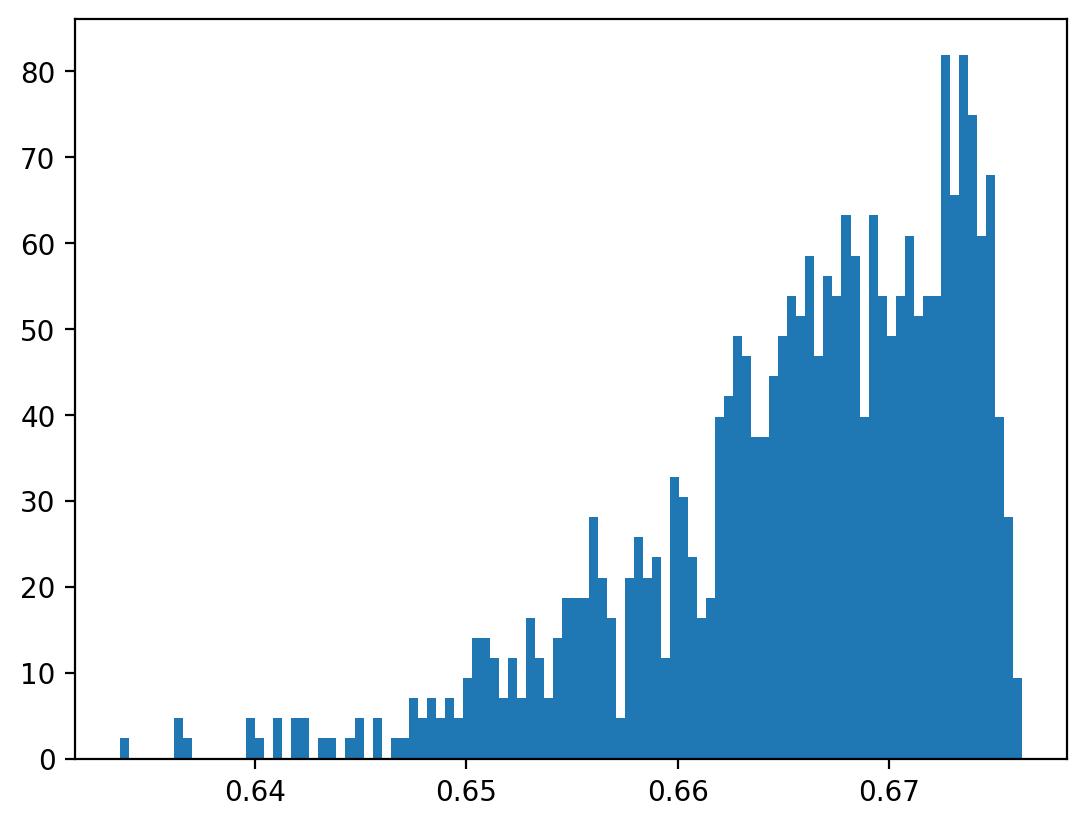

In [133]:
plt.hist(actions,100,density=True);

In [128]:
policy_input

Array([[ 0.13557091,  0.13557091,  1.08456731,  0.5566605 ,  0.5566605 ,
         4.45328399, -1.2063932 , -1.2063932 , -9.65114563]],      dtype=float64)